# SteamRec Evaluation Notebook (MongoDB)
This notebook evaluates recommendation approaches using your MongoDB data.
We will:
- Load data from `games` and `interactions`
- Clean and preprocess interactions
- Build train/test split
- Build a baseline recommender
- Train a library model (ALS)
- Compare models with Precision/Recall/NDCG
- Run a small hyperparameter search

## Imports
We load Python libraries for data handling, modeling, and evaluation.

In [1]:
import os
import pandas as pd
import numpy as np
from pymongo import MongoClient

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

## Connect to MongoDB
We connect to the `steamrec-test` database and load the `games` and `interactions` collections into DataFrames.

In [2]:
MONGO_URI = os.getenv("MONGODB_CONNECTION_STRING", "mongodb://localhost:27017")
DB_NAME = "steamrec-test"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]

games = pd.DataFrame(list(db["games"].find({})))
interactions = pd.DataFrame(list(db["interactions"].find({})))

print("games:", games.shape)
print("interactions:", interactions.shape)


games: (150405, 18)
interactions: (2828, 7)


## Inspect the raw data
We quickly inspect the first few rows so we can confirm the schema matches our expectations.

In [3]:
games.head(3)

,_id,AppId,Name,Genres,Categories,Tags,PriceEur,MetacriticScore,ReleaseYear,RequiredAge,IsFree,ReviewPositive,ReviewNegative,ReviewTotal,ReviewRatio,ReviewScoreAdj,ReviewVolumeLog,UpdatedUtc
0,6942ff9199ef832464837203,10,Counter-Strike,Action,Multi-player;PvP;Online PvP;Shared/Split Scree...,Action;FPS;Multiplayer;Shooter;Classic;Team-Ba...,1.63,88.0,2000,0,False,249308.0,6599.0,255907,0.974213,0.973592,5.408082,2025-12-28 10:30:47.772
1,6942ff9199ef832464837204,20,Team Fortress Classic,Action,Multi-player;PvP;Online PvP;Shared/Split Scree...,Action;FPS;Multiplayer;Classic;Hero Shooter;Sh...,1.24,0.0,1999,0,False,7806.0,1150.0,8956,0.871594,0.864506,3.952114,2025-12-28 10:30:33.449
2,6942ff9199ef832464837205,30,Day of Defeat,Action,Multi-player;Camera Comfort;Color Alternatives...,FPS;World War II;Multiplayer;Shooter;Action;Wa...,1.24,79.0,2003,0,False,6508.0,699.0,7207,0.903011,0.895962,3.857755,2025-12-28 10:30:49.222


## Inspect interactions
We check the playtime fields because they are key signals for our implicit rating.

In [4]:
interactions.head(3)

,_id,SteamId,AppId,PlaytimeForever,Playtime2Weeks,CreatedUtc,UpdatedUtc
0,000000000000000000000000,76561198164987397,220,182.0,0.0,2025-12-17 19:42:36.009,2026-01-02 20:18:54.683
1,69430a9999ef83246483b402,76561198080219056,220,793.0,0.0,NaT,2025-12-28 21:24:59.764
2,69430a9999ef83246483b403,76561198080219056,400,208.0,0.0,NaT,2025-12-28 21:24:59.764


## Explain the implicit rating formula
We use:

    log(1 + playtime_forever) + 0.35 * log(1 + playtime_2weeks)

**What it does:**
- `log(1 + playtime)` compresses large playtimes so a few huge values do not dominate.
- The `+1` avoids `log(0)` when playtime is zero.
- The `0.35` gives **recent playtime** some extra weight, without letting it overpower total playtime.

**Why we do this:**
- Raw minutes are extremely skewed (a few users play thousands of hours).
- Log scaling makes the data more stable and improves training.
- Recent playtime helps capture short‑term interest.

## Clean interactions
We remove:
- Missing Steam IDs or App IDs
- Zero playtime (no signal)
Then we compute the implicit rating using the same logic as your ML.NET model.

In [5]:
interactions = interactions.dropna(subset=["SteamId", "AppId"])
interactions = interactions[interactions["AppId"] > 0]

# Remove zero-signal rows
interactions = interactions[
    (interactions["PlaytimeForever"] > 0) | (interactions["Playtime2Weeks"] > 0)
]

# Implicit rating (same formula as ML.NET)
interactions["implicit_rating"] = (
    np.log1p(interactions["PlaytimeForever"].clip(lower=0))
    + 0.35 * np.log1p(interactions["Playtime2Weeks"].clip(lower=0))
)

interactions = interactions[interactions["implicit_rating"] > 0]
interactions.shape

(2828, 8)

## Filter low-signal users and games
If a user only has 1 interaction or a game only appears once, the model can’t learn patterns.
We filter them to reduce noise.

In [6]:
min_user_interactions = 5
min_game_interactions = 10

user_counts = interactions["SteamId"].value_counts()
game_counts = interactions["AppId"].value_counts()

valid_users = user_counts[user_counts >= min_user_interactions].index
valid_games = game_counts[game_counts >= min_game_interactions].index

interactions = interactions[
    interactions["SteamId"].isin(valid_users)
    & interactions["AppId"].isin(valid_games)
]

interactions.shape

(166, 8)

## Quick EDA
We view distributions to understand data size and sparsity.

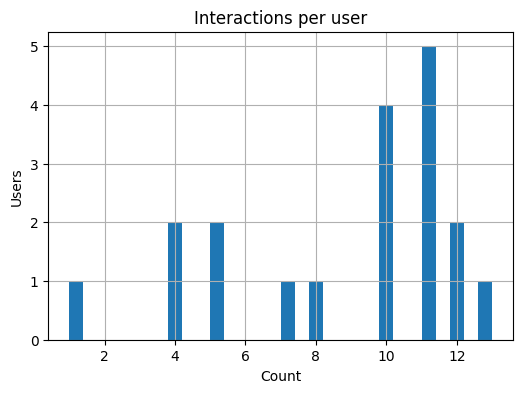

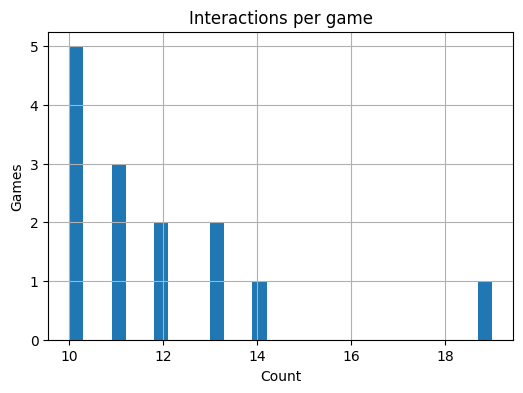

In [7]:
plt.figure(figsize=(6,4))
interactions["SteamId"].value_counts().hist(bins=30)
plt.title("Interactions per user")
plt.xlabel("Count")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(6,4))
interactions["AppId"].value_counts().hist(bins=30)
plt.title("Interactions per game")
plt.xlabel("Count")
plt.ylabel("Games")
plt.show()

## Train/Test Split (leave-one-out per user)
We hold out one interaction per user as a test item.
This is common for recommender evaluation.

In [8]:
interactions = interactions.sort_values("implicit_rating", ascending=False)

test_rows = interactions.groupby("SteamId").head(1)
train_rows = interactions.drop(test_rows.index)

print("train:", train_rows.shape, "test:", test_rows.shape)

train: (147, 8) test: (19, 8)


## Build user-item matrix
We map SteamId and AppId to matrix indices and build a sparse matrix.

In [9]:
user_ids = train_rows["SteamId"].unique()
item_ids = train_rows["AppId"].unique()

user_index = {u:i for i,u in enumerate(user_ids)}
item_index = {a:i for i,a in enumerate(item_ids)}
inv_item_index = {i:a for a,i in item_index.items()}

train_rows["u_idx"] = train_rows["SteamId"].map(user_index)
train_rows["i_idx"] = train_rows["AppId"].map(item_index)

matrix = csr_matrix(
    (train_rows["implicit_rating"], (train_rows["u_idx"], train_rows["i_idx"])),
    shape=(len(user_ids), len(item_ids))
)

## Baseline model: Popularity
A simple baseline: recommend the most played games.
This is used to compare against more complex models.

In [10]:
popularity = train_rows.groupby("AppId")["implicit_rating"].sum().sort_values(ascending=False)

def recommend_popular(user_id, k=10):
    return popularity.index[:k].tolist()

## Evaluation Metrics (Precision@K, Recall@K, NDCG@K)
These metrics measure ranking quality.
- Precision@K: how many recommended items are correct
- Recall@K: how many relevant items were retrieved
- NDCG@K: rewards correct items near the top of the list

In [11]:
def precision_recall_ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    hits = [1 if r in relevant else 0 for r in recommended]
    precision = np.sum(hits) / k if k else 0
    recall = np.sum(hits) / len(relevant) if relevant else 0
    
    dcg = np.sum([h / np.log2(i+2) for i,h in enumerate(hits)])
    idcg = np.sum([1 / np.log2(i+2) for i in range(min(len(relevant), k))])
    ndcg = dcg / idcg if idcg > 0 else 0
    return precision, recall, ndcg

## Evaluation loop
We test a recommendation function across all users.

In [12]:
def evaluate_model(recommend_fn, k=10):
    precisions, recalls, ndcgs = [], [], []
    
    for user_id, row in test_rows.groupby("SteamId"):
        relevant = set(row["AppId"])
        recs = recommend_fn(user_id, k)
        p, r, n = precision_recall_ndcg_at_k(recs, relevant, k)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)
    
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

## Evaluate baseline popularity model
This gives a reference point before using more complex models.

In [13]:
baseline_scores = evaluate_model(recommend_popular, k=10)
baseline_scores

(np.float64(0.021052631578947368),
 np.float64(0.21052631578947367),
 np.float64(0.08384524578337686))

In [14]:
print("matrix shape:", matrix.shape)

matrix shape: (18, 14)


## Train ALS (library model)
We use the `implicit` library to train Alternating Least Squares (matrix factorization).

In [15]:
from implicit.als import AlternatingLeastSquares

als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=20)
als.fit(matrix.T)  # implicit expects item-user matrix

c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0 seconds
  warnings.warn(
100%|██████████| 20/20 [00:00<00:00, 3300.91it/s

## Evaluate ALS model
We compare ALS performance with the baseline.

In [17]:
def recommend_als(user_id, k=10):
    if user_id not in user_index:
        return []
    uid = user_index[user_id]

    # Safety check: only recommend if ALS model has that user index
    if uid >= als.user_factors.shape[0]:
        return []

    ids, scores = als.recommend(uid, matrix[uid], N=k)
    return [inv_item_index[int(i)] for i in ids if int(i) in inv_item_index]

als_scores = evaluate_model(recommend_als, k=10)
als_scores


(np.float64(0.07368421052631581),
 np.float64(0.7368421052631579),
 np.float64(0.5147605161085108))

## Hyperparameter search
We test different ALS configurations and compare results.

In [19]:
param_grid = [
    {"factors": 32, "regularization": 0.01},
    {"factors": 64, "regularization": 0.05},
    {"factors": 128, "regularization": 0.1},
]

results = []
for params in param_grid:
    model = AlternatingLeastSquares(
        factors=params["factors"],
        regularization=params["regularization"],
        iterations=20
    )
    model.fit(matrix.T)
    
    def recommend_tmp(user_id, k=10):
        if user_id not in user_index:
            return []
        uid = user_index[user_id]
        if uid >= model.user_factors.shape[0]:
            return []
        ids, scores = model.recommend(uid, matrix[uid], N=k)
        return [inv_item_index[int(i)] for i in ids if int(i) in inv_item_index]
    
    scores = evaluate_model(recommend_tmp, k=10)
    results.append((params, scores))

results

c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0 seconds
  warnings.warn(
100%|██████████| 20/20 [00:00<00:00, 3564.16it/s]
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0 seconds
  warnings.warn(
100%|██████████| 20/20 [00:00<00:00, 4987.28it/s]
c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0 seconds
  warnings.warn(
100%|██████████| 20/20 [00:00<00:00, 2754.43it/s]


[({'factors': 32, 'regularization': 0.01},
  (np.float64(0.07368421052631581),
   np.float64(0.7368421052631579),
   np.float64(0.49005765400990653))),
 ({'factors': 64, 'regularization': 0.05},
  (np.float64(0.07368421052631581),
   np.float64(0.7368421052631579),
   np.float64(0.5338041250135657))),
 ({'factors': 128, 'regularization': 0.1},
  (np.float64(0.07368421052631581),
   np.float64(0.7368421052631579),
   np.float64(0.5516159474505142)))]

## Comparison table
We summarize baseline vs ALS and tuned models.

In [20]:
summary = pd.DataFrame([
    {"model": "Popularity baseline", "Precision@10": baseline_scores[0], "Recall@10": baseline_scores[1], "NDCG@10": baseline_scores[2]},
    {"model": "ALS (default)", "Precision@10": als_scores[0], "Recall@10": als_scores[1], "NDCG@10": als_scores[2]},
] + [
    {"model": f"ALS {params}", "Precision@10": score[0], "Recall@10": score[1], "NDCG@10": score[2]}
    for params, score in results
])

summary

,model,Precision@10,Recall@10,NDCG@10
0,Popularity baseline,0.021053,0.210526,0.083845
1,ALS (default),0.073684,0.736842,0.514761
2,"ALS {'factors': 32, 'regularization': 0.01}",0.073684,0.736842,0.490058
3,"ALS {'factors': 64, 'regularization': 0.05}",0.073684,0.736842,0.533804
4,"ALS {'factors': 128, 'regularization': 0.1}",0.073684,0.736842,0.551616
